In [1]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow as tf 
from tensorflow import keras

from tensorflow.keras.datasets import mnist

In [3]:
(x_train,y_train), (x_test,y_test) = mnist.load_data()

In [4]:
print("Shape of X Train: ",x_train.shape)
print("Shape of X Test: ",x_test.shape)
print("Shape of Y Train: ",y_train.shape)
print("Shape of Y Test: ",y_test.shape)

Shape of X Train:  (60000, 28, 28)
Shape of X Test:  (10000, 28, 28)
Shape of Y Train:  (60000,)
Shape of Y Test:  (10000,)


In [5]:
x_trian = x_train/255.0
x_test = x_test/255.0

In [6]:
print("Shape of X Train: ",x_train.shape)
print("Shape of X Test: ",x_test.shape)

Shape of X Train:  (60000, 28, 28)
Shape of X Test:  (10000, 28, 28)


In [7]:
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Shape of X Train: ",x_train.shape)
print("Shape of X Test: ",x_test.shape)

Shape of X Train:  (60000, 28, 28, 1)
Shape of X Test:  (10000, 28, 28, 1)


In [8]:
model = keras.Sequential([
    
    keras.Input(shape=(28, 28, 1)),

        
    keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    keras.layers.MaxPooling2D((2,2)),

    
    keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(
        64,
        activation='relu'
    ),

    keras.layers.Dense(
        10,
        activation='softmax'
    )
])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

In [11]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9126 - loss: 0.3807 - val_accuracy: 0.9773 - val_loss: 0.0838
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9797 - loss: 0.0702 - val_accuracy: 0.9825 - val_loss: 0.0591
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.9843 - loss: 0.0522 - val_accuracy: 0.9865 - val_loss: 0.0517
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9873 - loss: 0.0421 - val_accuracy: 0.9870 - val_loss: 0.0516
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9901 - loss: 0.0330 - val_accuracy: 0.9878 - val_loss: 0.0554
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9908 - loss: 0.0300 - val_accuracy: 0.9847 - val_loss: 0.0601
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9918 - loss: 0.0268 - val_accuracy: 0.9893 - val_loss: 0.0450
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9931 -

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)

In [13]:
conv_layer_1 = model.layers[0]

print("Name: ", conv_layer_1.name)
print("Number of Filters: ", conv_layer_1.filters)
print("Kernel Size: ", conv_layer_1.kernel_size)
print(conv_layer_1.get_weights()[0].shape)

Name:  conv2d
Number of Filters:  32
Kernel Size:  (3, 3)
(3, 3, 1, 32)


In [14]:
filters ,biases = conv_layer_1.get_weights()

print("Filters: ", filters.shape)
print("Biases: ", biases.shape)

Filters:  (3, 3, 1, 32)
Biases:  (32,)


In [15]:
print(filters[:, :, 0, 0])

[[-0.07367633  0.09092027 -0.17144622]
 [ 0.12797856 -0.12769665 -0.11385328]
 [-0.01293146 -0.11611691  0.06386144]]


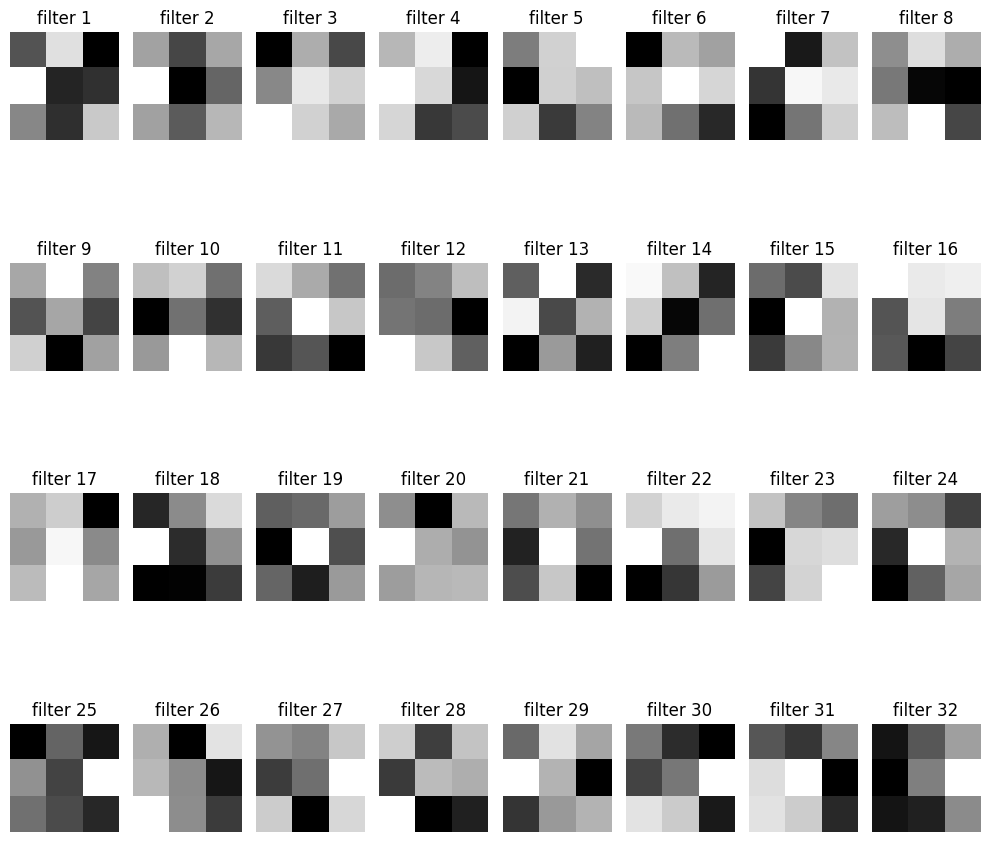

In [16]:
plt.figure(figsize=(10,10))

for i in range(32):
    plt.subplot(4,8,i+1)
    plt.imshow(filters[:, :, 0, i], cmap="gray")

    plt.axis("off")
    plt.title(f"filter {i+1}")

plt.tight_layout()
plt.show()

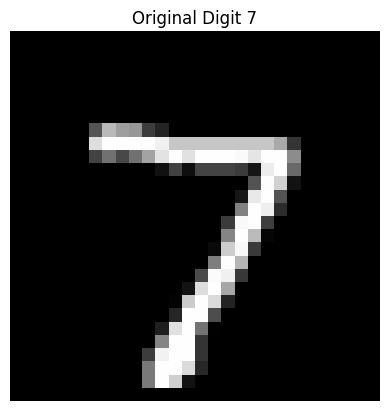

In [17]:
image = x_test[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Original Digit {y_test[0]}")
plt.axis("off")
plt.show()

In [18]:
input_image = tf.expand_dims(image, axis=0)

feature_maps = conv_layer_1(input_image)

print("Shape of Feature Maps: ", feature_maps.shape)

Shape of Feature Maps:  (1, 26, 26, 32)


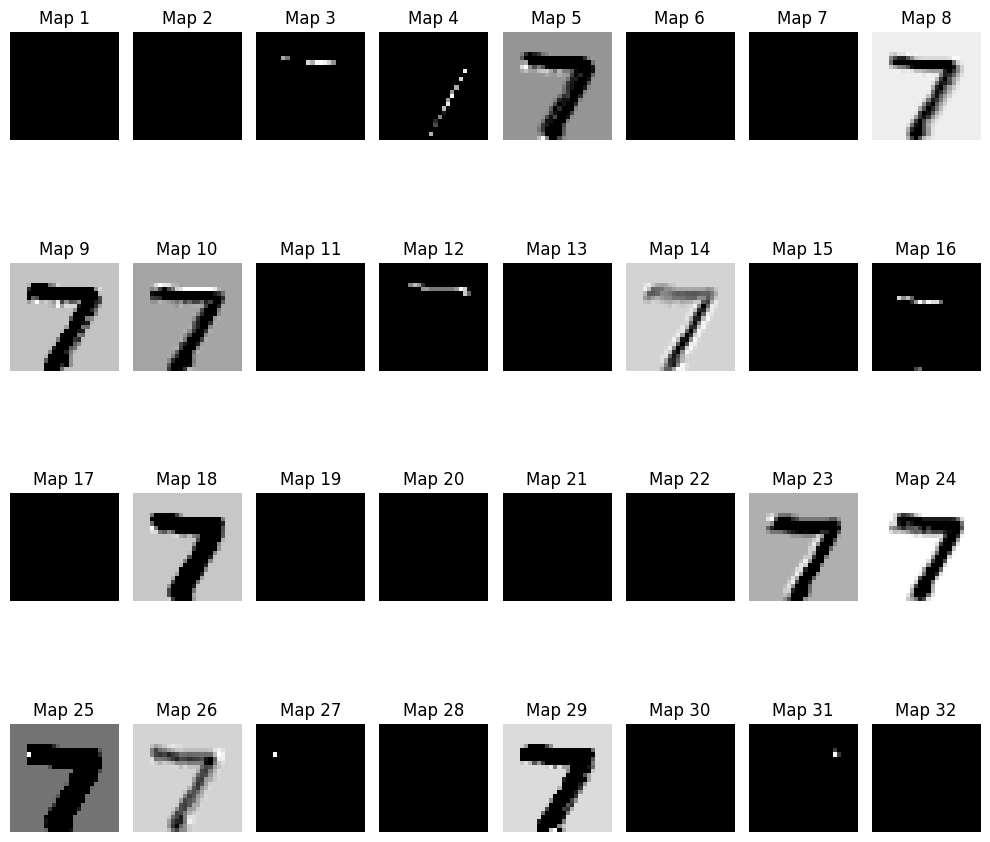

In [19]:
plt.figure(figsize=(10,10))

for i in range(32):
    plt.subplot(4,8,i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap="gray")
    plt.title(f"Map {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()